In [28]:
# Import libraries
import sys
import os

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image
import torch
from torchvision import transforms

from spair_dataset import SPair71kPairs, SPair71kImages

In [3]:
# Load the SPair-71k dataset
print("Loading SPair-71k dataset...")

# Set the path to your SPair-71k dataset
# Update this path to point to the directory containing the SPair-71k folder
dataset_root = "../data/"

# Create datasets for each split
train_dataset = SPair71kPairs(root=dataset_root, split='train')
val_dataset = SPair71kPairs(root=dataset_root, split='val')
test_dataset = SPair71kPairs(root=dataset_root, split='test')

# Create a dictionary to mimic the old structure
dataset = {
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset
}

print(f"\nDataset loaded successfully!")
print(f"Dataset splits: {dataset.keys()}")
print(f"Training set size: {len(dataset['train'])} pairs")
print(f"Validation set size: {len(dataset['validation'])} pairs")
print(f"Test set size: {len(dataset['test'])} pairs")

Loading SPair-71k dataset...

Dataset loaded successfully!
Dataset splits: dict_keys(['train', 'validation', 'test'])
Training set size: 53340 pairs
Validation set size: 5384 pairs
Test set size: 12234 pairs


# Visualize SPair-71k samples
The cell below displays a few sample image pairs from the `train` split. It shows the source and target images side-by-side and overlays keypoints (red) and bounding boxes (green) when available. Run the previous cells first so `dataset` is defined.

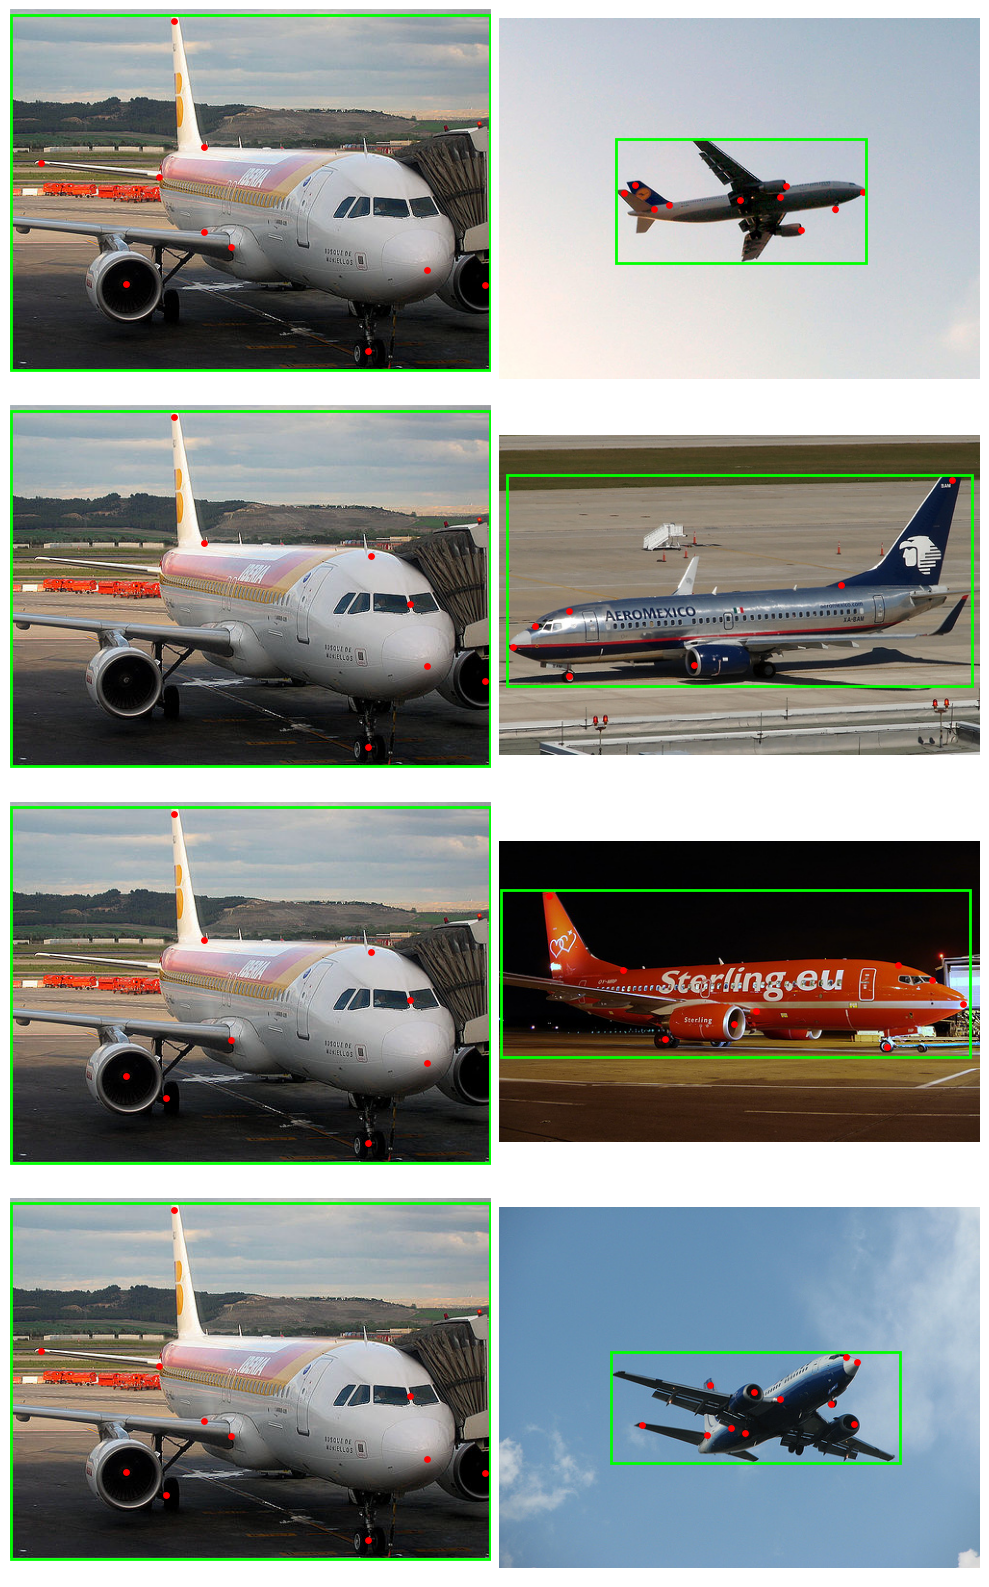

In [12]:
# Visualize a few sample pairs
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

def load_img(img_obj):
    # Images are now PIL Image objects or tensors
    if isinstance(img_obj, Image.Image):
        return img_obj
    elif isinstance(img_obj, torch.Tensor):
        # Convert tensor to PIL
        from torchvision import transforms as T
        return T.ToPILImage()(img_obj)
    return img_obj

def draw_bbox(ax, bbox):
    if bbox is None or len(bbox) == 0:
        return
    # SPair bbox format: [xmin, ymin, xmax, ymax]
    try:
        if isinstance(bbox, (torch.Tensor, np.ndarray)):
            bbox = bbox.tolist() if isinstance(bbox, torch.Tensor) else bbox.tolist()
        x0, y0, x1, y1 = bbox
        w = x1 - x0
        h = y1 - y0
        rect = patches.Rectangle((x0, y0), w, h, linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
    except Exception as e:
        print(f"Error drawing bbox: {e}")
        return

def plot_pair(sample, ax_left, ax_right):
    src = load_img(sample.get('src_img'))
    trg = load_img(sample.get('trg_img'))
    ax_left.imshow(src)
    ax_left.axis('off')
    ax_right.imshow(trg)
    ax_right.axis('off')

    # keypoints (if available)
    src_kps = sample.get('src_kps')
    trg_kps = sample.get('trg_kps')
    if src_kps is not None and len(src_kps):
        kps = np.array(src_kps) if not isinstance(src_kps, np.ndarray) else src_kps
        ax_left.scatter(kps[:,0], kps[:,1], c='r', s=15)
    if trg_kps is not None and len(trg_kps):
        kps = np.array(trg_kps) if not isinstance(trg_kps, np.ndarray) else trg_kps
        ax_right.scatter(kps[:,0], kps[:,1], c='r', s=15)

    # bounding boxes (if available)
    draw_bbox(ax_left, sample.get('src_bndbox'))
    draw_bbox(ax_right, sample.get('trg_bndbox'))

# Show a few samples from the train split
n = 4
fig, axes = plt.subplots(n, 2, figsize=(10, 4*n))
for i in range(n):
    sample = dataset['train'][i]
    plot_pair(sample, axes[i,0], axes[i,1])

plt.tight_layout()
plt.show()

In [13]:
# Display sample information
print("Sample data structure:")
sample = dataset['train'][0]
for key, value in sample.items():
    if isinstance(value, np.ndarray):
        print(f"  {key}: numpy.ndarray with shape {value.shape}")
    elif isinstance(value, (list, tuple)):
        print(f"  {key}: {type(value).__name__} of length {len(value)}")
    elif isinstance(value, Image.Image):
        print(f"  {key}: PIL.Image with size {value.size}")
    else:
        print(f"  {key}: {type(value).__name__}")

Sample data structure:
  pair_id: int
  src_img: PIL.Image with size (500, 375)
  src_segmentation: PIL.Image with size (500, 375)
  src_name: str
  src_imsize: numpy.ndarray with shape (3,)
  src_bndbox: numpy.ndarray with shape (4,)
  src_pose: str
  src_kps: numpy.ndarray with shape (10, 2)
  trg_img: PIL.Image with size (500, 375)
  trg_segmentation: PIL.Image with size (500, 375)
  trg_name: str
  trg_imsize: numpy.ndarray with shape (3,)
  trg_bndbox: numpy.ndarray with shape (4,)
  trg_pose: str
  trg_kps: numpy.ndarray with shape (10, 2)
  kps_ids: numpy.ndarray with shape (10,)
  category: str
  category_id: int
  viewpoint_variation: int
  scale_variation: int
  truncation: int
  occlusion: int


In [19]:
# Check the keys of the first sample
print(dataset['train'][0].keys())

dict_keys(['pair_id', 'src_img', 'src_segmentation', 'src_name', 'src_imsize', 'src_bndbox', 'src_pose', 'src_kps', 'trg_img', 'trg_segmentation', 'trg_name', 'trg_imsize', 'trg_bndbox', 'trg_pose', 'trg_kps', 'kps_ids', 'category', 'category_id', 'viewpoint_variation', 'scale_variation', 'truncation', 'occlusion'])


In [41]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
import torchvision.transforms.functional as TF  # Renamed to TF to avoid conflict

# 1. Ensure Config is correct
MODEL_CONFIGS['dinov2'] = {
    'img_size': 518,
    'patch_size': 14,
    'mean': [0.485, 0.456, 0.406],
    'std': [0.229, 0.224, 0.225],
    'interpolation': T.InterpolationMode.BICUBIC 
}
cfg = MODEL_CONFIGS['dinov2']

# 2. Redefine Dataset Class with specific 'TF' alias
class ResizedSPairDataset(Dataset):
    def __init__(self, dataset, config):
        self.dataset = dataset
        self.cfg = config
        self.normalize = T.Compose([
            T.ToTensor(),
            T.Normalize(mean=self.cfg['mean'], std=self.cfg['std'])
        ])

    def __len__(self):
        return len(self.dataset)

    def _process_single(self, img, kps, bbox):
        # Ensure image is RGB
        img = img.convert('RGB')
        w_orig, h_orig = img.size
        
        target_size = (self.cfg['img_size'], self.cfg['img_size'])
        
        # USE TF (torchvision) HERE
        img_resized = TF.resize(img, target_size, interpolation=self.cfg['interpolation'])
        
        # Calculate scale factors
        scale_w = target_size[0] / w_orig
        scale_h = target_size[1] / h_orig
        
        # Scale Keypoints
        kps_t = torch.tensor(kps).float()
        kps_resized = kps_t.clone()
        kps_resized[:, 0] *= scale_w
        kps_resized[:, 1] *= scale_h
        
        # Scale Bounding Box
        bbox_t = torch.tensor(bbox).float()
        bbox_resized = bbox_t.clone()
        bbox_resized[0] *= scale_w
        bbox_resized[1] *= scale_h
        bbox_resized[2] *= scale_w
        bbox_resized[3] *= scale_h
        
        img_tensor = self.normalize(img_resized)
        
        return img_tensor, kps_resized, bbox_resized, torch.tensor([w_orig, h_orig])

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        
        src_img, src_kps, src_bbox, src_size = self._process_single(
            sample['src_img'], sample['src_kps'], sample['src_bndbox']
        )
        
        trg_img, trg_kps, trg_bbox, trg_size = self._process_single(
            sample['trg_img'], sample['trg_kps'], sample['trg_bndbox']
        )
        
        return {
            'src_img': src_img, 'src_kps': src_kps, 'src_bbox': src_bbox, 'src_size': src_size,
            'trg_img': trg_img, 'trg_kps': trg_kps, 'trg_bbox': trg_bbox, 'trg_size': trg_size,
            'category': sample['category'],
            'pair_id': sample['pair_id']
        }

# 3. Re-instantiate the dataset
resized_train = ResizedSPairDataset(dataset['train'], config=cfg)
print("Dataset class updated and re-instantiated.")

Dataset class updated and re-instantiated.


In [42]:
# Verify DINOv2 feature extraction on a resized sample pair
import torch
from dinov2_features import DINOv2FeatureExtractor

device = 'cuda' if torch.cuda.is_available() else 'cpu'
extractor = DINOv2FeatureExtractor(model_name='dinov2_vits14', device=device)

def describe_features(features, label):
    # Move to CPU for analysis
    feats = features.detach().cpu()
    
    # Check dimensions
    # DINOv2 output is usually (Batch, C, H, W) or (Batch, N_patches, C)
    # If it's flattened (Batch, N, C), we won't have grid_h/grid_w directly.
    # Assuming the extractor returns spatial feature maps (B, C, H, W):
    if feats.dim() == 4:
        grid_h, grid_w = feats.shape[-2], feats.shape[-1]
        
        # CORRECTED LINE: Use bracket notation and correct keys
        expected = cfg['img_size'] // cfg['patch_size']
        
        print(f"{label}: shape={tuple(feats.shape)}")
        print(f"  > Grid sizes: {grid_h}x{grid_w} (Expected: {expected}x{expected})")
        print(f"  > Stats: mean={feats.mean().item():.4f}, std={feats.std().item():.4f}")
    else:
        # Fallback for flattened features
        print(f"{label}: shape={tuple(feats.shape)} (Flattened or CLS token)")

# --- Run the verification ---
# 1. Get a sample
sample = resized_train[0]
src_tensor = sample['src_img'].unsqueeze(0).cuda() # Add batch dim

# 2. Extract
# Ensure your extractor is loaded and on the correct device
# extractor = ... (Your DINOv2 extractor instance)
if 'extractor' in locals():
    with torch.no_grad():
        feats = extractor.extract_features(src_tensor)
        describe_features(feats, "Source Image Features")
else:
    print("Extractor not found. Please initialize your DINOv2 extractor first.")

Loading dinov2_vits14 on cuda...


Using cache found in C:\Users\Juva/.cache\torch\hub\facebookresearch_dinov2_main


Source Image Features: shape=(1, 384, 37, 37)
  > Grid sizes: 37x37 (Expected: 37x37)
  > Stats: mean=0.0005, std=0.0510


torch.Size([1, 384, 37, 37])


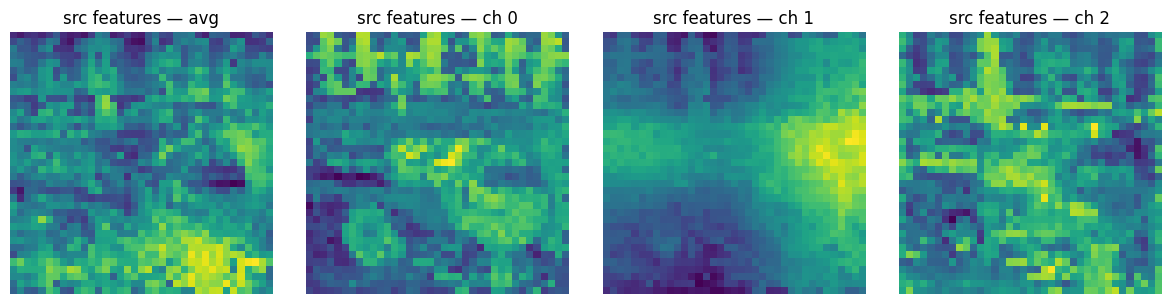

torch.Size([1, 384, 37, 37])


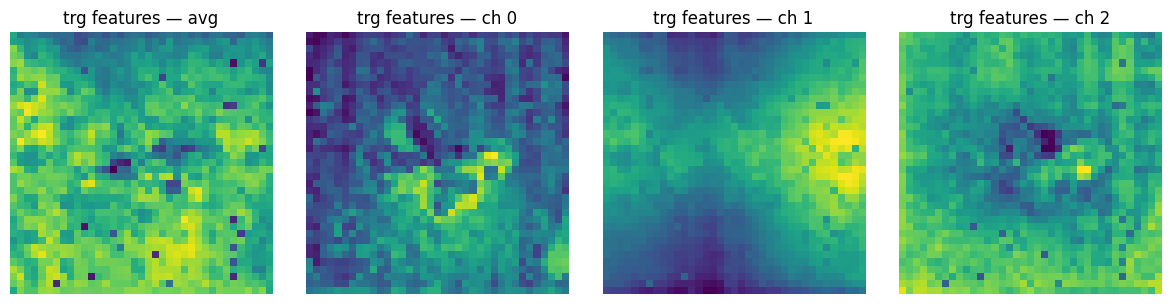

In [43]:
# Plot DINOv2 feature maps for the same resized pair
import matplotlib.pyplot as plt

def show_feature_grid(features, title):
    features = features.detach().cpu()
    avg_map = features.mean(dim=1).squeeze(0).numpy()
    channels = min(3, features.shape[1])
    channel_maps = [features[0, ch].numpy() for ch in range(channels)]
    all_maps = [avg_map] + channel_maps
    fig, axes = plt.subplots(1, len(all_maps), figsize=(3 * len(all_maps), 3))
    if not hasattr(axes, '__iter__') or isinstance(axes, plt.Axes):
        axes = [axes]
    for ax, fmap, label in zip(axes, all_maps, ['avg'] + [f'ch {i}' for i in range(channels)]):
        ax.imshow(fmap, cmap='viridis', interpolation='nearest')
        ax.set_title(f"{title} — {label}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

sample_idx = 0
sample_keypairs = [('src', resized_train[sample_idx]['src_img']), ('trg', resized_train[sample_idx]['trg_img'])]
for label, tensor in sample_keypairs:
    tensor = tensor.unsqueeze(0).to(device)
    feats = extractor.extract_features(tensor)
    print(feats.shape)

        
    show_feature_grid(feats, f"{label} features")

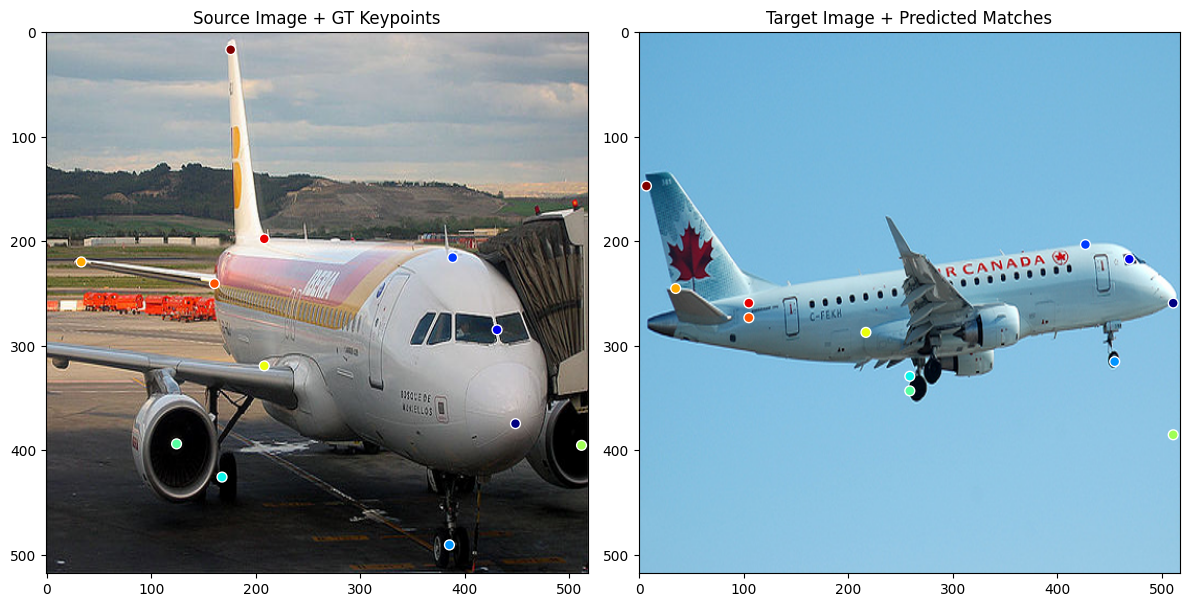

In [44]:
def find_pair(src_feats, src_keypoint, trg_feats):
    keypoint_feat = src_feats[:, int(src_keypoint[1]), int(src_keypoint[0])]
    max_sim = -1.0
    max_sim_pos = None
    rows = trg_feats.shape[1]
    cols = trg_feats.shape[2]
    for row in range(rows):
        for col in range(cols):
            f = trg_feats[:, row, col] # 384 x 1 x 1
            sim = torch.cosine_similarity(keypoint_feat.unsqueeze(0), f.unsqueeze(0)).item()
            if sim > max_sim:
                max_sim = sim
                max_sim_pos = (row, col)
    return (max_sim, max_sim_pos)


def find_pairs(src_feats, src_kps, trg_feats, patch_size=14):
    """
    Finds the corresponding location in the target image for each source keypoint
    using Nearest Neighbor search in the feature space.
    
    Args:
        src_feats: Source features (C, H_grid, W_grid)
        src_kps: Source keypoints (N, 2) in pixel coordinates
        trg_feats: Target features (C, H_grid, W_grid)
        patch_size: Size of the patch (e.g., 14 for DINOv2)
    """
    C, H, W = src_feats.shape
    
    # 1. Map Source Keypoints (pixels) -> Feature Grid Coordinates
    # We divide by patch_size to find which "grid cell" the keypoint falls into.
    # Note: We clamp to ensure we don't go out of bounds.
    grid_y = (src_kps[:, 1] / patch_size).long().clamp(0, H - 1)
    grid_x = (src_kps[:, 0] / patch_size).long().clamp(0, W - 1)
    
    # 2. Extract Feature Vectors for Source Keypoints
    # We select the vectors at the grid locations (grid_y, grid_x)
    # src_vecs shape: (N_kps, C)
    src_vecs = src_feats[:, grid_y, grid_x].t() 
    
    # 3. Flatten Target Features for searching
    # trg_flat shape: (C, H*W) -> transpose to (H*W, C)
    trg_flat = trg_feats.flatten(1).t()
    
    # 4. Normalize vectors for Cosine Similarity
    src_vecs = F.normalize(src_vecs, dim=1)
    trg_flat = F.normalize(trg_flat, dim=1)
    
    # 5. Calculate Similarity Matrix
    # (N_kps, C) @ (C, H*W) -> (N_kps, H*W)
    sim_matrix = torch.mm(src_vecs, trg_flat.t())
    
    # 6. Find Best Matches (Nearest Neighbor)
    # Get index of max similarity for each keypoint
    best_vals, best_indices = sim_matrix.max(dim=1)
    
    # 7. Convert best indices back to (x, y) coordinates
    # The indices are in the flattened range [0, H*W]
    pred_y = (best_indices // W)
    pred_x = (best_indices % W)
    
    # Map back to pixels (center of the patch)
    pred_kps = torch.stack([pred_x, pred_y], dim=1).float() * patch_size + (patch_size / 2)
    
    return pred_kps

def plot_keypoints_matching(dataset, sample_idx, extractor, cfg):
    """
    Visualizes the DINOv2 matching capability.
    """
    sample = dataset[sample_idx]
    
    # Prepare tensors (add batch dim, move to GPU)
    src_tensor = sample['src_img'].unsqueeze(0).cuda()
    trg_tensor = sample['trg_img'].unsqueeze(0).cuda()
    
    # Extract Features
    with torch.no_grad():
        src_feats = extractor.extract_features(src_tensor)[0] # Remove batch dim -> (C, H, W)
        trg_feats = extractor.extract_features(trg_tensor)[0]
    
    # Find Matches
    # Ensure keypoints are on the same device/type as needed
    src_kps_cpu = sample['src_kps'] # usually tensor on CPU
    predicted_trg_kps = find_pairs(src_feats, src_kps_cpu, trg_feats, patch_size=cfg['patch_size'])
    
    # --- VISUALIZATION ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Fix: Access dict using brackets ['mean']
    src_img_pil = _unnormalize_to_pil(sample['src_img'], cfg['mean'], cfg['std'])
    trg_img_pil = _unnormalize_to_pil(sample['trg_img'], cfg['mean'], cfg['std'])
    
    # Plot Source
    axes[0].imshow(src_img_pil)
    axes[0].set_title("Source Image + GT Keypoints")
    axes[0].scatter(src_kps_cpu[:, 0], src_kps_cpu[:, 1], c=range(len(src_kps_cpu)), cmap='jet', s=50, edgecolors='white')
    
    # Plot Target
    axes[1].imshow(trg_img_pil)
    axes[1].set_title("Target Image + Predicted Matches")
    # We color the points with the same cmap to show correspondence
    axes[1].scatter(predicted_trg_kps[:, 0].cpu(), predicted_trg_kps[:, 1].cpu(), c=range(len(src_kps_cpu)), cmap='jet', s=50, edgecolors='white')
    
    plt.tight_layout()
    plt.show()

# Run the fixed block
plot_keypoints_matching(resized_train, sample_idx=9, extractor=extractor, cfg=cfg)


In [47]:
from pck import calculate_pck

# 1. Get a single sample from the already loaded train_dataset
sample_idx = 12999
sample = train_dataset[sample_idx]

# Extract Ground Truth data
# Note: Adjust keys if your dataset uses different names (e.g. 'trg_kps', 'target_kps')
gt_kps = sample['trg_kps']      # Expected shape: (N, 2)
bbox = sample['trg_bndbox']     # Expected shape: (4,) -> [x1, y1, x2, y2]

print(f"Testing PCK on Sample {sample_idx}")
print(f"Ground Truth Keypoints Shape: {gt_kps.shape}")
print(f"Bounding Box: {bbox}")

# 2. Simulate Predictions
# Case A: Perfect Prediction (Should correspond to PCK = 1.0)
pred_kps_perfect = torch.tensor(gt_kps).float()

# Case B: Noisy Prediction (Simulating a model)
# Add random noise of 5 pixels
noise = torch.randn_like(pred_kps_perfect) * 5.0 
pred_kps_noisy = pred_kps_perfect + noise

# Case C: Bad Prediction (Should correspond to PCK = 0.0)
# Add massive offset (e.g., 500 pixels)
pred_kps_bad = pred_kps_perfect + 500.0

# 3. Calculate PCK for each case
pck_perfect, _ = calculate_pck(pred_kps_perfect, gt_kps, bbox, alpha=0.1)
pck_noisy, _ = calculate_pck(pred_kps_noisy, gt_kps, bbox, alpha=0.1)
pck_bad, _ = calculate_pck(pred_kps_bad, gt_kps, bbox, alpha=0.1)

# 4. Print Results
print("-" * 30)
print(f"PCK (Perfect Prediction): {pck_perfect:.4f} (Expected: 1.0)")
print(f"PCK (Noisy +/- 5px)     : {pck_noisy:.4f} (Expected: ~0.5 - 1.0 depending on object size)")
print(f"PCK (Bad Prediction)    : {pck_bad:.4f} (Expected: 0.0)")
print("-" * 30)

if pck_perfect == 1.0 and pck_bad == 0.0:
    print("PCK Function Test Passed!")
else:
    print("PCK Function Test Failed. Check tensor shapes or bbox format.")

Testing PCK on Sample 12999
Ground Truth Keypoints Shape: (10, 2)
Bounding Box: [256 205 352 496]
------------------------------
PCK (Perfect Prediction): 1.0000 (Expected: 1.0)
PCK (Noisy +/- 5px)     : 1.0000 (Expected: ~0.5 - 1.0 depending on object size)
PCK (Bad Prediction)    : 0.0000 (Expected: 0.0)
------------------------------
PCK Function Test Passed!
